In [1]:
from scipy import misc, ndimage
import numpy as np
import matplotlib.pyplot as plt

import scipy.io.wavfile
import scipy.signal
import sounddevice


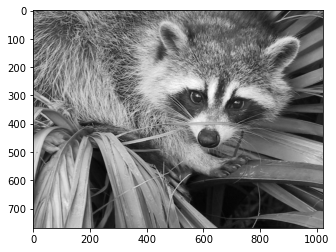

In [2]:
X = misc.face(gray=True)
plt.imshow(X, cmap=plt.cm.gray)
plt.show()

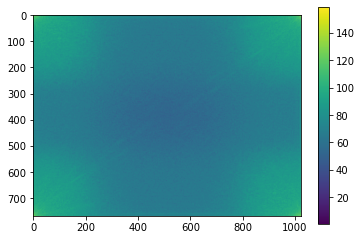

In [3]:
Y = np.fft.fft2(X)
freq_db = 20*np.log10(abs(Y))

plt.imshow(freq_db)
plt.colorbar()
plt.show()


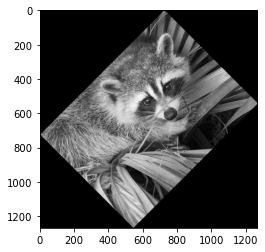

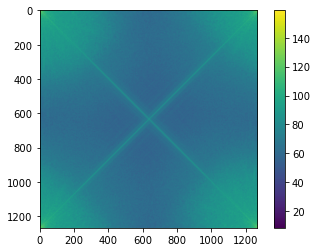

In [4]:
rotate_angle = 45
X45 = ndimage.rotate(X, rotate_angle)
plt.imshow(X45, cmap=plt.cm.gray)
plt.show()

Y45 = np.fft.fft2(X45)
plt.imshow(20*np.log10(abs(Y45)))
plt.colorbar()
plt.show()


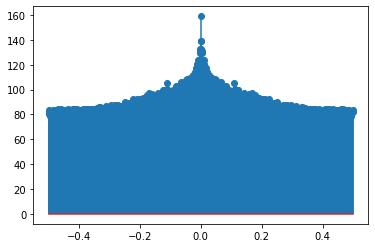

In [5]:
freq_x = np.fft.fftfreq(X.shape[1])
freq_y = np.fft.fftfreq(X.shape[0])

plt.stem(freq_x, freq_db[:][0])
plt.show()

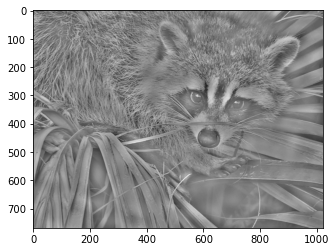

In [6]:
def freq_cutoff(Y, freq_cutoff = 120):
    freq_db = 20*np.log10(abs(Y))
    Y_cutoff = Y.copy()
    Y_cutoff[freq_db > freq_cutoff] = 0
    X_cutoff = np.fft.ifft2(Y_cutoff)
    X_cutoff = np.real(X_cutoff)    # avoid rounding erros in the complex domain,
                                    # in practice use irfft2
    return X_cutoff

Y = np.fft.fft2(X)
plt.imshow(freq_cutoff(Y, 120), cmap=plt.cm.gray)
plt.show()

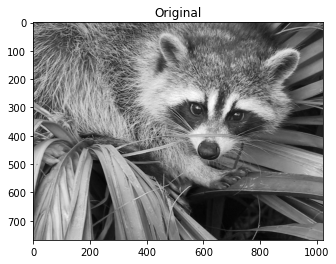

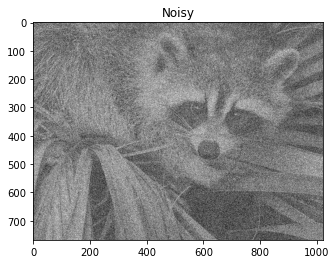

In [7]:
def get_noisy(X, pixel_noise = 200):
    noise = np.random.randint(-pixel_noise, high=pixel_noise+1, size=X.shape)
    X_noisy = X + noise
    return X_noisy

plt.imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.show()

X_noisy = get_noisy(X, 200)
plt.imshow(X_noisy, cmap=plt.cm.gray)
plt.title('Noisy')
plt.show()

In [8]:
# ex 1

def get_new_signal(N, func):
    new_signal = np.empty((N,N), dtype=float)
    
    for i in range(N):
        for j in range(N):
            new_signal[i][j] = func(i, j, N)
    
    return new_signal

def get_new_signal_v2(N, func):
    new_signal = np.empty((N,N), dtype=float)
    
    aux = np.linspace(0, 1, N)
    
    for i in range(N):
        for j in range(N):
            new_signal[i][j] = func(aux[i], aux[j], N)
    
    return new_signal

def show1(X, signal1, use_log = True):
    N = len(X)
    X1 = get_new_signal_v2(N, signal1)
    plt.imshow(X1, )
    plt.title("Time Domain")
    plt.show()

    Y1 = np.fft.fft2(X1)
    
    freq_db = 20*np.log10(abs(Y1[:N//2][:N//2])) if use_log else abs(Y1[:N//2][:N//2])

    plt.imshow(freq_db)
    plt.title("Frequency Domain")
    plt.colorbar()
    plt.show()

def show1_cde(length, signal1, use_log = False):  
    Y1 = get_new_signal(length, signal1)

    plt.imshow(abs(Y1))
    plt.title("Frequency Domain")
    plt.colorbar()
    plt.show()
    
    X1 = np.fft.ifft2(Y1)
    plt.title("Time Domain")
    plt.imshow(X1)
    plt.show()
    

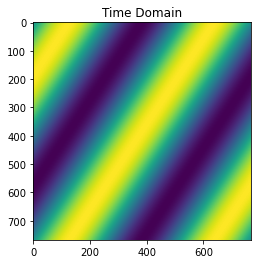

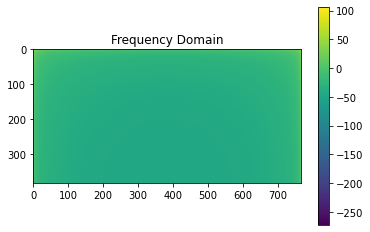

In [9]:
# a
def signal1a(n1, n2, N = None):
    return np.sin(2*np.pi*n1 + 3*np.pi*n2)

show1(X, signal1a)


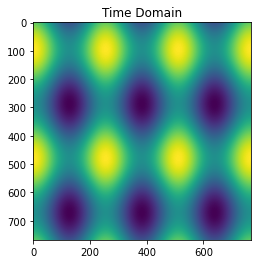

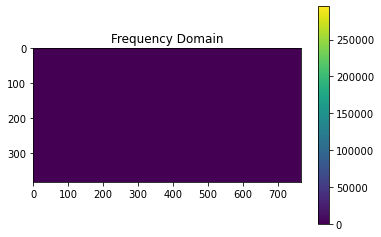

In [10]:
# b
def signal1b(n1, n2, N = None):
    return np.sin(4*np.pi*n1) + np.cos(6*np.pi*n2)

show1(X, signal1b, False)


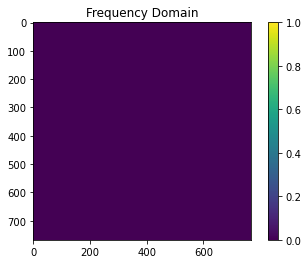

TypeError: Image data of dtype complex128 cannot be converted to float

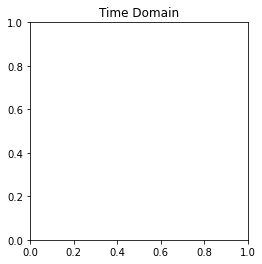

In [11]:
# c
def signal1c(m1, m2, N):
    if m1 == 0 and (m2 == 5 or m2 == N - 5):
        return 1
    return 0

show1_cde(len(X), signal1c)


In [ ]:
# d
def signal1d(m1, m2, N):
    if m2 == 0 and (m1 == 5 or m1 == N - 5):
        return 1
    return 0  

show1_cde(len(X), signal1d)


In [ ]:
# e
def signal1e(m1, m2, N):
    if(m1 == m2 and (m1 == 5 or m1 == N - 5)):
        return 1
    return 0

show1_cde(len(X), signal1e)


In [ ]:
# ex 2
# 2_1

Y2_1 = np.fft.fft2(X)
X2_1_cutoff = freq_cutoff(Y2_1, 105)

plt.imshow(X2_1_cutoff, cmap=plt.cm.gray)
plt.title("Cutoff")
plt.show()


In [ ]:
# 2_2
X_noisy2_2 = get_noisy(X, 190)

plt.imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.show()

plt.imshow(X_noisy, cmap=plt.cm.gray)
plt.title('Noisy')
plt.show()

Y2_2 = np.fft.fft2(X_noisy2_2)
X2_2_cutoff = freq_cutoff(Y2_2, 350)

plt.imshow(X_noisy, cmap=plt.cm.gray)
plt.title('Cutoff')
plt.show()


In [12]:
# 2_3
path = "F:\CollegeProjects\AudacityProjects\PSLab6\ps-lab-mix.wav"

rate, X_song = scipy.io.wavfile.read(path)
time_unit = len(X_song)//9
X_song_section = X_song[7*time_unit : 9*time_unit]

Y_song_section = np.fft.fft2(X_song_section)
X_song_section_cutoff = freq_cutoff(Y_song_section, 200)

sounddevice.play(X_song_section_cutoff, 44100)
